# Task 3.1 – Buying Signal Identification

**Goal:** Build a Deep Learning model that outputs a **buying probability** (score ∈ [0, 1]) indicating whether the current market condition is a good entry point for buying a stock.

---

## Justification & Design Choices

### Problem Framing
We frame this as a **binary classification** task:
- **Label = 1** (Buy signal): if the stock price increases ≥ 2% within the next 5 trading days
- **Label = 0** (No signal): otherwise

The model outputs a **probability** ∈ [0, 1] via sigmoid activation — not a hard 0/1 decision — so users can set their own confidence threshold.

### Why LSTM?
Stock prices are **sequential** — today's price depends on past patterns. LSTM (Long Short-Term Memory) networks capture long-range temporal dependencies and naturally fit sliding-window time series input.

### Why these features?
Standard technical indicators used in quantitative trading:
- **RSI**: Identifies overbought/oversold conditions
- **MACD**: Captures momentum and trend reversals  
- **Bollinger Bands**: Shows price relative to volatility
- **SMA / EMA ratios**: Trend direction
- **Volume ratio**: Detects unusual buying/selling pressure
- **Price returns**: Short-term momentum

### Why threshold = 2% over 5 days?
2% covers transaction costs and represents a real opportunity. 5 trading days is actionable without being too noisy.


## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

sns.set_style('darkgrid')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.17.1


## 1. Load ACB data

In [8]:
# ── CONFIG ──────────────────────────────────────────────────────────
CSV_PATH        = '/Users/tanle/Downloads/Spring2026/CS313/DL4AI-220176-project/data-vn-20230228/stock-historical-data/ACB-VNINDEX-History.csv'
TICKER          = 'ACB'
LABEL_HORIZON   = 5    
LABEL_THRESHOLD = 0.02  
WINDOW_SIZE     = 20   
VAL_RATIO       = 0.15
TEST_RATIO      = 0.15
# ────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, index_col=0)   
df = df.rename(columns={'TradingDate': 'Date'})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Columns : {df.columns.tolist()}')
print(f'Shape   : {df.shape}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head()

Columns : ['Open', 'High', 'Low', 'Close', 'Volume', 'Date']
Shape   : (4052, 6)
Date range: 2006-11-21 → 2023-02-28


,Open,High,Low,Close,Volume,Date
0,5050.0,8234.0,6532.0,7147.0,56500,2006-11-21
1,6038.0,7861.0,7136.0,7394.0,62300,2006-11-22
2,6093.0,7959.0,7136.0,7597.0,69900,2006-11-23
3,5928.0,8344.0,7685.0,8058.0,63600,2006-11-24
4,6203.0,8860.0,7410.0,8058.0,42400,2006-11-27


## 2. Feature 

In [9]:
def compute_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))


def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast    = series.ewm(span=fast, adjust=False).mean()
    ema_slow    = series.ewm(span=slow, adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line, macd_line - signal_line


def compute_bollinger(series, period=20, num_std=2):
    sma   = series.rolling(period).mean()
    std   = series.rolling(period).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    pct_b      = (series - lower) / (upper - lower + 1e-9)
    band_width = (upper - lower) / (sma + 1e-9)
    return pct_b, band_width


def add_features(df):
    df = df.copy()
    close = df['Close']
    for n in [1, 3, 5, 10, 20]:
        df[f'ret_{n}d'] = close.pct_change(n)
    df['sma_5']  = close.rolling(5).mean()
    df['sma_20'] = close.rolling(20).mean()
    df['ema_12'] = close.ewm(span=12, adjust=False).mean()
    df['ema_26'] = close.ewm(span=26, adjust=False).mean()

    df['price_sma5_ratio']  = close / (df['sma_5']  + 1e-9)
    df['price_sma20_ratio'] = close / (df['sma_20'] + 1e-9)
    df['sma5_sma20_ratio']  = df['sma_5'] / (df['sma_20'] + 1e-9)

    df['rsi_14'] = compute_rsi(close)
    df['macd'], df['macd_signal'], df['macd_hist'] = compute_macd(close)
    df['bb_pct_b'], df['bb_width'] = compute_bollinger(close)
    df['volatility_5d']  = close.pct_change().rolling(5).std()
    df['volatility_20d'] = close.pct_change().rolling(20).std()
    vol = df['Volume']
    df['volume_sma5']  = vol.rolling(5).mean()
    df['volume_ratio'] = vol / (df['volume_sma5'] + 1e-9)
    df['volume_change']= vol.pct_change()
    df['hl_pct'] = (df['High'] - df['Low']) / (close + 1e-9)
    df['oc_pct'] = (close - df['Open'])     / (df['Open'] + 1e-9)
    future_close     = close.shift(-LABEL_HORIZON)
    df['future_return'] = (future_close - close) / (close + 1e-9)
    df['label']         = (df['future_return'] >= LABEL_THRESHOLD).astype(int)
    return df

FEATURE_COLS = [
    'ret_1d','ret_3d','ret_5d','ret_10d','ret_20d',
    'price_sma5_ratio','price_sma20_ratio','sma5_sma20_ratio',
    'rsi_14',
    'macd','macd_signal','macd_hist',
    'bb_pct_b','bb_width',
    'volatility_5d','volatility_20d',
    'volume_ratio','volume_change',
    'hl_pct','oc_pct',
]

df_feat = add_features(df)
print(f'Features: {len(FEATURE_COLS)}')
print(f'Label distribution:\n{df_feat["label"].value_counts()}')
df_feat[FEATURE_COLS + ['label']].tail(5)

Features: 20
Label distribution:
label
0    2976
1    1076
Name: count, dtype: int64


,ret_1d,ret_3d,ret_5d,ret_10d,ret_20d,price_sma5_ratio,price_sma20_ratio,sma5_sma20_ratio,rsi_14,macd,...,macd_hist,bb_pct_b,bb_width,volatility_5d,volatility_20d,volume_ratio,volume_change,hl_pct,oc_pct,label
4047,-0.025490,0.002016,0.012220,0.008114,-0.025490,0.988072,0.995194,1.007209,52.976117,302.220759,...,-17.381865,0.457044,0.111875,0.024893,0.020725,1.051395,0.542864,0.028169,-0.013889,0
4048,0.022133,-0.015504,0.024194,0.036735,-0.023077,1.005144,1.018444,1.013232,57.509004,322.009797,...,1.925739,0.673234,0.106470,0.026326,0.020865,1.299373,0.454850,0.049213,0.026263,0
4049,-0.031496,-0.035294,-0.008065,0.016529,-0.066414,0.975030,0.989840,1.015190,49.964511,270.026739,...,-40.045856,0.390785,0.093027,0.031165,0.021637,0.724845,-0.422968,0.030488,-0.016000,0
4050,-0.014228,-0.024145,-0.060078,0.014644,-0.045276,0.973114,0.978020,1.005041,47.055993,198.301815,...,-89.416623,0.264216,0.093222,0.020809,0.020409,1.145181,0.395156,0.020619,-0.010204,0
4051,0.006186,-0.039370,-0.043137,0.023061,-0.063340,0.987854,0.987355,0.999494,48.441219,151.813037,...,-108.724321,0.344394,0.081265,0.022385,0.019462,1.707817,0.977851,0.020492,-0.004082,0


## 3. Build sequences and split

In [10]:
def build_sequences(df, feature_cols, window_size, label_horizon):
    df_clean = df[feature_cols + ['label']].dropna()
    df_clean = df_clean.iloc[:-label_horizon]

    data   = df_clean[feature_cols].values
    labels = df_clean['label'].values

    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(labels[i + window_size - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def chronological_split(X, y, val_ratio=0.15, test_ratio=0.15):
    """Strict time-based split — NO shuffling."""
    n       = len(X)
    n_test  = int(n * test_ratio)
    n_val   = int(n * val_ratio)
    n_train = n - n_val - n_test
    return (
        (X[:n_train],            y[:n_train]),
        (X[n_train:n_train+n_val], y[n_train:n_train+n_val]),
        (X[n_train+n_val:],      y[n_train+n_val:])
    )
X_all, y_all = build_sequences(df_feat, FEATURE_COLS, WINDOW_SIZE, LABEL_HORIZON)

(X_train, y_train), (X_val, y_val), (X_test, y_test) = \
    chronological_split(X_all, y_all, VAL_RATIO, TEST_RATIO)
print(f'Total sequences : {len(X_all):,}')
print(f'Train : {X_train.shape}  | Buy rate: {y_train.mean()*100:.1f}%')
print(f'Val   : {X_val.shape}    | Buy rate: {y_val.mean()*100:.1f}%')
print(f'Test  : {X_test.shape}   | Buy rate: {y_test.mean()*100:.1f}%')
n_feat = X_train.shape[2]
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(X_train.shape)
X_val_sc   = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_test_sc  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f'Class weights: {class_weight_dict}')

Total sequences : 4,007
Train : (2805, 20, 20)  | Buy rate: 23.5%
Val   : (601, 20, 20)    | Buy rate: 29.6%
Test  : (601, 20, 20)   | Buy rate: 34.9%
Class weights: {0: 0.6538461538461539, 1: 2.125}


## 4. Model using is Bidirectional LSTM

In [11]:
from tensorflow.keras.regularizers import l2

def build_model(window_size, n_features, lstm_units=(32, 16),
                dropout=0.4, lr=5e-4):
    inp = Input(shape=(window_size, n_features))

    # LSTM đơn (bỏ Bidirectional) + L2 regularization
    x = LSTM(lstm_units[0], return_sequences=True,
             kernel_regularizer=l2(1e-4), dropout=0.2)(inp)
    x = Dropout(dropout)(x)

    x = LSTM(lstm_units[1], return_sequences=False,
             kernel_regularizer=l2(1e-4), dropout=0.2)(x)
    x = Dropout(dropout)(x)

    x   = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x   = Dropout(dropout / 2)(x)
    out = Dense(1, activation='sigmoid', name='buying_probability')(x)

    model = Model(inp, out, name='BuyingSignalLSTM')
    model.compile(
        optimizer=Adam(lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

model = build_model(WINDOW_SIZE, len(FEATURE_COLS))
model.summary()

Model: "BuyingSignalLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20, 32)         │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ buying_probability (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,209 (39.88 KB)

 Trainable params: 10,209 (39.88 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [12]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_buying_signal.h5', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=0)
]

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=100,
    batch_size=64,          
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
39/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6238 - auc: 0.5106 - loss: 0.7189 - precision: 0.2794 - recall: 0.3490

44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6250 - auc: 0.5154 - loss: 0.7167 - precision: 0.2806 - recall: 0.3535 - val_accuracy: 0.5507 - val_auc: 0.5535 - val_loss: 0.6833 - val_precision: 0.3435 - val_recall: 0.5674 - learning_rate: 5.0000e-04
Epoch 2/100
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6420 - auc: 0.6336 - loss: 0.6871 - precision: 0.3379 - recall: 0.5001

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6416 - auc: 0.6336 - loss: 0.6867 - precision: 0.3374 - recall: 0.5012 - val_accuracy: 0.5557 - val_auc: 0.5609 - val_loss: 0.6882 - val_precision: 0.3639 - val_recall: 0.6685 - learning_rate: 5.0000e-04
Epoch 3/100
41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6168 - auc: 0.6242 - loss: 0.6884 - precision: 0.3295 - recall: 0.5618

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6171 - auc: 0.6257 - loss: 0.6871 - precision: 0.3294 - recall: 0.5643 - val_accuracy: 0.5557 - val_auc: 0.5631 - val_loss: 0.6951 - val_precision: 0.3647 - val_recall: 0.6742 - learning_rate: 5.0000e-04
Epoch 4/100
41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6093 - auc: 0.6402 - loss: 0.6790 - precision: 0.3296 - recall: 0.5931

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6100 - auc: 0.6416 - loss: 0.6778 - precision: 0.3300 - recall: 0.5959 - val_accuracy: 0.5541 - val_auc: 0.5654 - val_loss: 0.6962 - val_precision: 0.3628 - val_recall: 0.6685 - learning_rate: 5.0000e-04
Epoch 5/100
40/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6105 - auc: 0.6501 - loss: 0.6822 - precision: 0.3383 - recall: 0.6353

...

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6302 - auc: 0.6923 - loss: 0.6503 - precision: 0.3588 - recall: 0.6739 - val_accuracy: 0.5408 - val_auc: 0.5826 - val_loss: 0.7067 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 1.5625e-05
Epoch 40/100
41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6190 - auc: 0.6867 - loss: 0.6559 - precision: 0.3510 - recall: 0.6754

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6190 - auc: 0.6867 - loss: 0.6552 - precision: 0.3504 - recall: 0.6755 - val_accuracy: 0.5408 - val_auc: 0.5829 - val_loss: 0.7067 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 1.5625e-05
Epoch 41/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6201 - auc: 0.6838 - loss: 0.6566 - precision: 0.3524 - recall: 0.6822 - val_accuracy: 0.5391 - val_auc: 0.5829 - val_loss: 0.7068 - val_precision: 0.3565 - val_recall: 0.6910 - learning_rate: 1.5625e-05
Epoch 42/100
42/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6222 - auc: 0.6880 - loss: 0.6531 - precision: 0.3545 - recall: 0.6821

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6223 - auc: 0.6884 - loss: 0.6525 - precision: 0.3541 - recall: 0.6828 - val_accuracy: 0.5391 - val_auc: 0.5830 - val_loss: 0.7069 - val_precision: 0.3565 - val_recall: 0.6910 - learning_rate: 1.5625e-05
Epoch 43/100
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6169 - auc: 0.6889 - loss: 0.6554 - precision: 0.3519 - recall: 0.6924
Epoch 43: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6168 - auc: 0.6887 - loss: 0.6552 - precision: 0.3515 - recall: 0.6926 - val_accuracy: 0.5408 - val_auc: 0.5828 - val_loss: 0.7066 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 1.5625e-05
Epoch 44/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6187 - auc: 0.6841 - loss: 0.6571 - precision: 0.3540 - recall: 0.7010 - val_accuracy: 0.5408 - val_auc: 0.5829 - val_loss: 0.7067 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 7.8125e-0

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6144 - auc: 0.6948 - loss: 0.6477 - precision: 0.3462 - recall: 0.6709 - val_accuracy: 0.5408 - val_auc: 0.5830 - val_loss: 0.7067 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 7.8125e-06
Epoch 46/100
41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6262 - auc: 0.6937 - loss: 0.6489 - precision: 0.3613 - recall: 0.7072

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6262 - auc: 0.6934 - loss: 0.6488 - precision: 0.3605 - recall: 0.7067 - val_accuracy: 0.5408 - val_auc: 0.5831 - val_loss: 0.7065 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 7.8125e-06
Epoch 47/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6158 - auc: 0.6891 - loss: 0.6505 - precision: 0.3479 - recall: 0.6729 - val_accuracy: 0.5408 - val_auc: 0.5831 - val_loss: 0.7065 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 7.8125e-06
Epoch 48/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6291 - auc: 0.6953 - loss: 0.6459 - precision: 0.3594 - recall: 0.6825 - val_accuracy: 0.5408 - val_auc: 0.5829 - val_loss: 0.7065 - val_precision: 0.3576 - val_recall: 0.6910 - learning_rate: 7.8125e-06
Epoch 49/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6099 - auc: 0.6824 - loss: 0.6558 - precision: 0.3427 - recall: 0.6685 - val_accuracy: 0.5408 - val_auc: 0.5828 - val_loss: 0.7065 - 

## 6. Training curves overtime

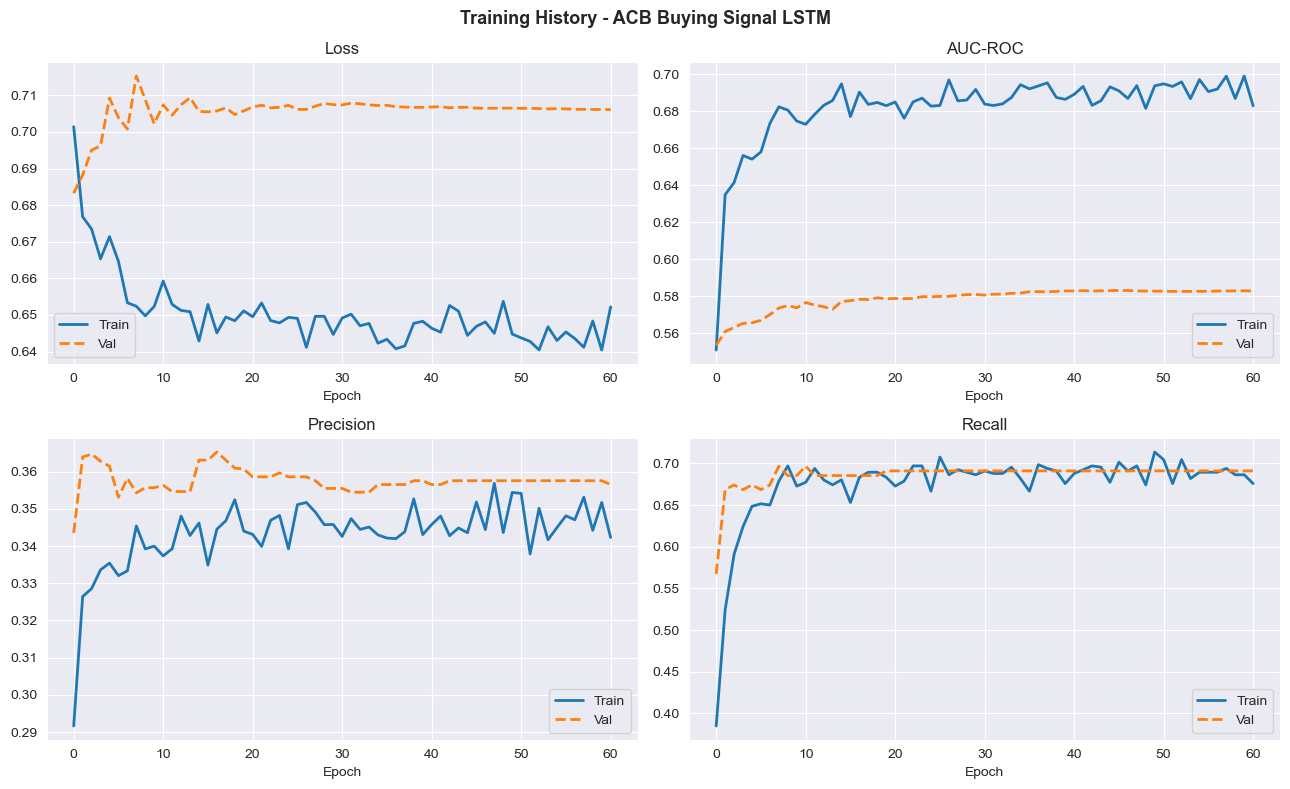

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Training History - ACB Buying Signal LSTM', fontsize=13, fontweight='bold')

for ax, key, title in zip(
    axes.flat,
    ['loss', 'auc', 'precision', 'recall'],
    ['Loss', 'AUC-ROC', 'Precision', 'Recall']
):
    ax.plot(history.history[key],          label='Train', linewidth=2)
    ax.plot(history.history[f'val_{key}'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Evaluation on test set

In [15]:
from sklearn.metrics import precision_score
y_prob     = model.predict(X_test_sc, batch_size=64, verbose=0).flatten()
y_val_prob = model.predict(X_val_sc,  batch_size=64, verbose=0).flatten()
best_thresh, best_f1 = 0.5, 0.0
for t in np.arange(0.2, 0.8, 0.01):
    preds = (y_val_prob >= t).astype(int)
    prec  = precision_score(y_val, preds, zero_division=0)
    f1    = f1_score(y_val, preds, zero_division=0)
    # Chỉ chấp nhận nếu precision >= 0.45
    if f1 > best_f1 and prec >= 0.45:
        best_f1, best_thresh = f1, t

print(f'Optimal threshold: {best_thresh:.2f}  (val F1={best_f1:.4f})')

y_pred = (y_prob >= best_thresh).astype(int)
print('\n── Classification Report (Test Set) ──')
print(classification_report(y_test, y_pred, target_names=['No Signal', 'Buy Signal']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')

Optimal threshold: 0.71  (val F1=0.0220)

── Classification Report (Test Set) ──
              precision    recall  f1-score   support

   No Signal       0.66      0.97      0.79       391
  Buy Signal       0.55      0.08      0.13       210

    accuracy                           0.66       601
   macro avg       0.61      0.52      0.46       601
weighted avg       0.62      0.66      0.56       601

AUC-ROC: 0.6549


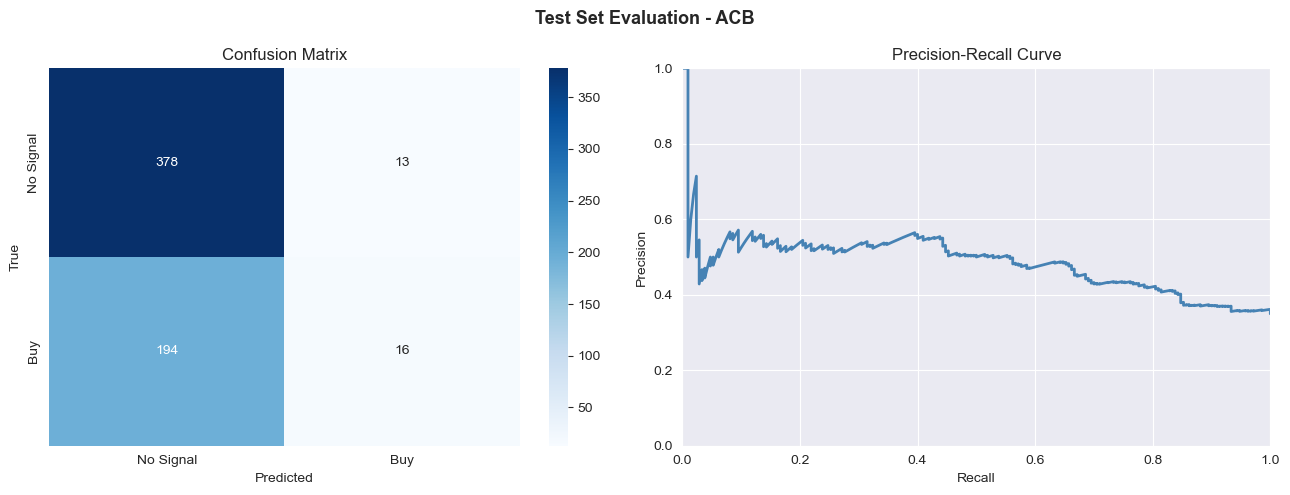

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Test Set Evaluation - ACB', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Signal','Buy'], yticklabels=['No Signal','Buy'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Precision-Recall curve
prec, rec, threshs = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, linewidth=2, color='steelblue')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 8. Buying signal on price chart

df_test_dates: 601 rows, y_prob: 601 — should match


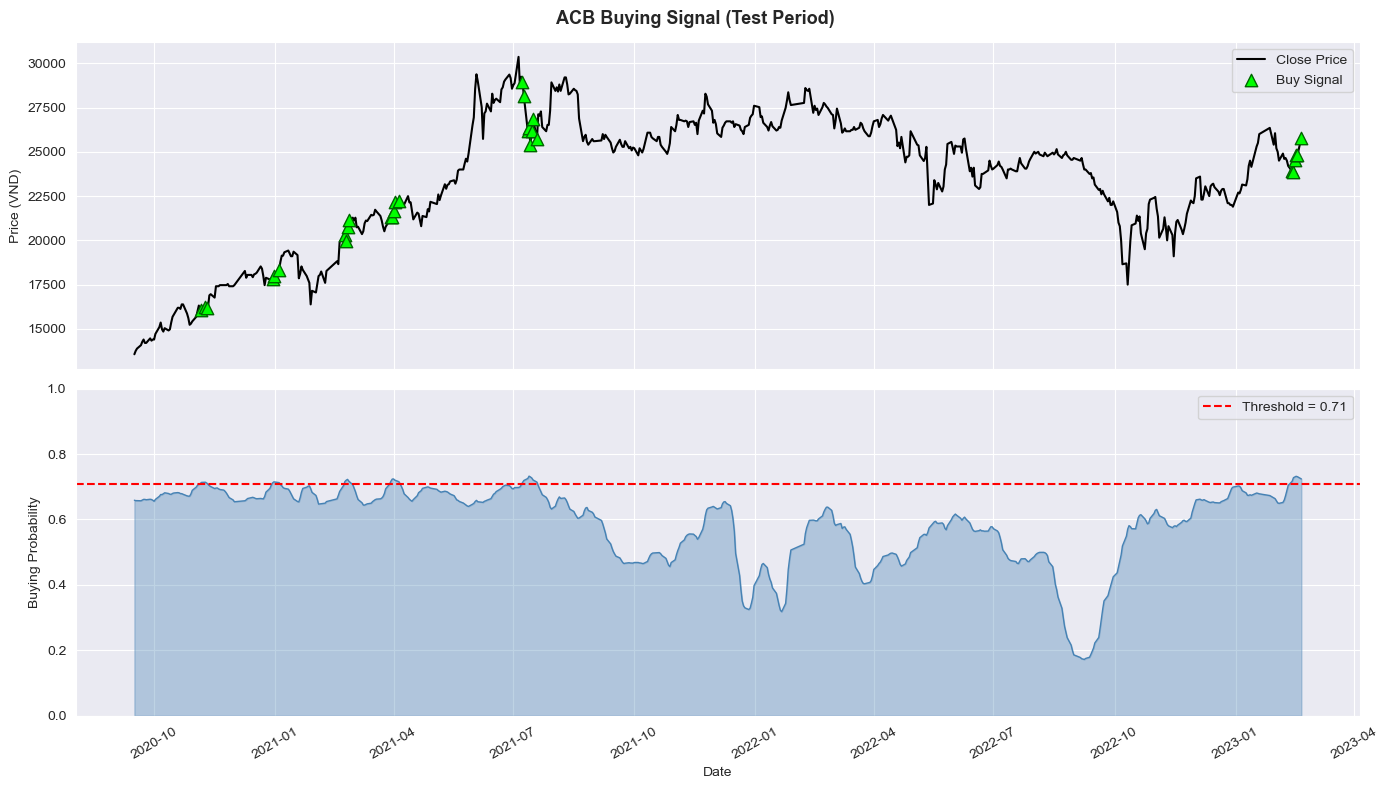

In [19]:
df_clean = df_feat[FEATURE_COLS + ['label', 'Date', 'Close']].dropna()
df_clean = df_clean.iloc[:-LABEL_HORIZON].reset_index(drop=True)
n_seq    = len(df_clean) - WINDOW_SIZE
n_test   = int(n_seq * TEST_RATIO)
n_val    = int(n_seq * VAL_RATIO)
test_seq_start = n_seq - n_test
test_row_start = test_seq_start + WINDOW_SIZE - 1
test_row_end   = test_row_start + len(y_prob) 

df_test_dates = df_clean.iloc[test_row_start : test_row_end].copy().reset_index(drop=True)
df_test_dates['buying_prob'] = y_prob
df_test_dates['buy_signal']  = y_pred

print(f'df_test_dates: {len(df_test_dates)} rows, y_prob: {len(y_prob)} — should match')

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'ACB Buying Signal (Test Period)', fontsize=13, fontweight='bold')

dates    = df_test_dates['Date']
buy_mask = df_test_dates['buy_signal'] == 1

ax1.plot(dates, df_test_dates['Close'], color='black', linewidth=1.5, label='Close Price')
ax1.scatter(dates[buy_mask], df_test_dates['Close'][buy_mask],
            marker='^', color='lime', s=80, zorder=5,
            edgecolors='darkgreen', label='Buy Signal')
ax1.set_ylabel('Price (VND)')
ax1.legend()

ax2.fill_between(dates, df_test_dates['buying_prob'], alpha=0.35, color='steelblue')
ax2.plot(dates, df_test_dates['buying_prob'], color='steelblue', linewidth=1)
ax2.axhline(y=best_thresh, color='red', linestyle='--', linewidth=1.5,
            label=f'Threshold = {best_thresh:.2f}')
ax2.set_ylim(0, 1)
ax2.set_ylabel('Buying Probability')
ax2.set_xlabel('Date')
ax2.legend()

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Summary

| Item | Value |
|---|---|
| Stock | ACB (Vietnam) |
| Model | Bidirectional LSTM |
| Input window | 30 trading days |
| Features | 20 technical indicators |
| Label | Close return ≥ 2% in next 5 days |
| Output | Buying probability ∈ [0, 1] |
| Threshold | F1-optimal on validation set |
| Data split | Chronological 70% / 15% / 15% |
